In [1]:
from IPython.display import Image, display, Markdown


def print_state(state):
    if not "messages" in state:
        return

    for message in state["messages"]:
        if isinstance(message, SystemMessage):
            print("💻" * 15, "SYSTEM MESSAGE", "💻" * 15)

        elif isinstance(message, AIMessage):
            print("🤖" * 15, "AI MESSAGE", "🤖" * 15)

            if hasattr(message, "tool_calls"):
                print(message.tool_calls)

        elif isinstance(message, HumanMessage):
            print(" " * 40, "👱🏻‍♀️" * 15, "HUMAN MESSAGE", "👱🏻‍♀️" * 15)
            message.content = " " * 30 + message.content

        else:
            print("🔨" * 15, "TOOL MESSAGE", "🔨" * 15)

        print(message.content)
        print("🚀" * 50)
        print("\n\n")

In [2]:
import pandas as pd
import numpy as np
from typing import List, Optional, Literal, Union, Dict, Any, Tuple, Type, TypedDict, Annotated
import os
import json
from abc import ABC

# Pydantic v2 imports
from pydantic import BaseModel, Field, ValidationError

# Langchain/Langgraph imports
from langchain_core.tools import BaseTool
from langchain_core.utils.function_calling import convert_to_openai_tool
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, ToolMessage, BaseMessage
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages

# Scikit-learn and Category Encoders imports
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

### LLM

In [3]:
import getpass
import os

os.environ["GROQ_API_KEY"] = getpass.getpass()

LLAMA_8B = "llama3-8b-8192"
LLAMA_70B = "llama3-70b-8192"
GEMMA2_9B = "gemma2-9b-it"

model = ChatGroq(model=LLAMA_8B)

 ········


In [4]:
llm = model

In [5]:
llm.invoke("Hi")

AIMessage(content="Hi! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 11, 'total_tokens': 36, 'completion_time': 0.020833333, 'prompt_time': 0.002452963, 'queue_time': 0.236312136, 'total_time': 0.023286296}, 'model_name': 'llama3-8b-8192', 'system_fingerprint': 'fp_a97cfe35ae', 'finish_reason': 'stop', 'logprobs': None}, id='run-ead2b258-ca96-446e-8324-fa593846c346-0', usage_metadata={'input_tokens': 11, 'output_tokens': 25, 'total_tokens': 36})

In [6]:
from ml_agent.feature_transform_agent.toolkit.toolkit import FeatureEngineeringToolkit

In [7]:
toolkit = FeatureEngineeringToolkit()
tools = toolkit.get_tools()
llm_with_tools = llm.bind_tools(tools=tools, tool_choice="any") # Let LLM choose one tool

### Nodes

In [8]:
class FeatureEngineeringState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages] # Accumulates messages
    dataframe: pd.DataFrame              # The DataFrame being modified
    dataframe_info: str                  # String representation of df.info() for context
    original_request: str                # User's initial request (for context)
    action_log: List[str]                # Log of successful actions
    error: Optional[str]                 # Any error message encountered

# === 6. Define Graph Nodes ===

def get_df_info(df: pd.DataFrame) -> str:
    """Gets DataFrame info as a string."""
    import io
    buffer = io.StringIO()
    df.info(buf=buffer)
    return buffer.getvalue()


def start_node(state: FeatureEngineeringState) -> FeatureEngineeringState:
    """Initializes the process and adds the first human message."""
    print("--- Starting Feature Engineering ---")
    df = state['dataframe']
    state['dataframe_info'] = get_df_info(df)
    state['action_log'] = []
    state['error'] = None

    # Add the initial request as the first message
    state['messages'] = [HumanMessage(content=state['original_request'])]

    print("Initial DataFrame Info:")
    print(state['dataframe_info'])
    return state

def interpret_request_node(state: FeatureEngineeringState) -> FeatureEngineeringState:
    """Interprets the user's request using the LLM with tools."""
    print(f"\n--- Interpreting Request ---")
    current_messages = state['messages']
    original_request = state['original_request'] # Keep original request for context if needed
    df_info = state['dataframe_info']

    # Construct prompt for the LLM
    # Include DataFrame info in the system prompt or first user message for context
    prompt_messages = [
        SystemMessage(content=f"""
You are an expert feature engineering assistant. Your goal is to understand the user's request
and select the single most appropriate tool to apply to the pandas DataFrame.

Current DataFrame Summary:
{df_info}

Analyze the latest user message and choose the best tool and parameters to fulfill the request.
Only select one tool per turn. If the request is ambiguous or cannot be fulfilled with the available tools,
respond asking for clarification or stating the limitation, but do *not* call a tool.
"""),
        *current_messages # Include history
    ]


    try:
        ai_response = llm_with_tools.invoke(prompt_messages)
        print(f"LLM Response: {ai_response.content}") # Log LLM's text response
        # Add AI response (including potential tool calls) to state
        state['messages'] = add_messages(state['messages'], [ai_response])
        state['error'] = None # Clear previous errors if LLM call succeeds

        # Check for tool calls before proceeding
        if not ai_response.tool_calls:
             print("LLM did not select a tool. It might be asking for clarification or the request is unfulfillable.")
             # No tool call means we might finish or need more info depending on the response
             # We'll handle this in the conditional edge

    except Exception as e:
        error_msg = f"Error during LLM call: {e}"
        print(f"Error: {error_msg}")
        state['error'] = error_msg
        # Add error as a message? Or just use the error flag.
        # state['messages'] = add_messages(state['messages'], [SystemMessage(content=f"Error: {error_msg}")])


    return state


def execute_tool_node(state: FeatureEngineeringState) -> FeatureEngineeringState:
    """Executes the tool chosen by the LLM."""
    print("\n--- Executing Tool ---")
    ai_message = state['messages'][-1] # Get the latest AI message
    if not isinstance(ai_message, AIMessage) or not ai_message.tool_calls:
        print("No tool call found in the last AI message. Skipping execution.")
        # This case should ideally be handled by the conditional edge, but double-check
        return state

    tool_call = ai_message.tool_calls[0] # Assuming one tool call per turn for simplicity
    tool_name = tool_call['name']
    tool_args = tool_call['args']
    tool_call_id = tool_call['id']

    print(f"Attempting to execute tool: {tool_name} with args: {tool_args}")

    # Find the corresponding tool in the toolkit
    selected_tool : Optional[BaseTool] = None
    for t in tools:
        if t.name == tool_name:
            selected_tool = t
            break

    if not selected_tool:
        error_msg = f"Error: Tool '{tool_name}' not found in the toolkit."
        print(error_msg)
        state['error'] = error_msg
        state['messages'] = add_messages(state['messages'], [ToolMessage(content=error_msg, tool_call_id=tool_call_id)])
        return state

    # Execute the tool's _run method, passing the current DataFrame explicitly
    current_df = state['dataframe']
    try:
        # Validate arguments using the tool's args_schema before calling _run
        validated_args = selected_tool.args_schema(**tool_args)

        # Call the tool's _run method, passing df and validated args
        # We rely on the specific tool's _run signature accepting current_df
        modified_df, log_message = selected_tool._run(**validated_args.model_dump(), current_df=current_df)

        # Update state on success
        state['dataframe'] = modified_df
        state['action_log'].append(log_message)
        state['dataframe_info'] = get_df_info(modified_df) # Update df info
        state['error'] = None # Clear error on success
        print(f"Execution successful: {log_message}")
        print("Updated DataFrame Info:")
        print(state['dataframe_info'])

        # Add ToolMessage confirming success
        state['messages'] = add_messages(state['messages'], [ToolMessage(content=f"Success: {log_message}", tool_call_id=tool_call_id)])

    except ValidationError as e:
        error_msg = f"Error: Invalid arguments provided for tool '{tool_name}'. Details: {e}"
        print(error_msg)
        state['error'] = error_msg
        state['messages'] = add_messages(state['messages'], [ToolMessage(content=error_msg, tool_call_id=tool_call_id)])

    except (ValueError, TypeError, RuntimeError, KeyError) as e:
        # Catch specific errors from our implementation functions
        error_msg = f"Error executing tool '{tool_name}': {e}"
        print(error_msg)
        state['error'] = error_msg
        state['messages'] = add_messages(state['messages'], [ToolMessage(content=error_msg, tool_call_id=tool_call_id)])
        # Keep the DataFrame as it was before the failed attempt

    except Exception as e:
        # Catch any other unexpected errors
        error_msg = f"Unexpected error executing tool '{tool_name}': {e}"
        print(error_msg)
        state['error'] = error_msg
        state['messages'] = add_messages(state['messages'], [ToolMessage(content=error_msg, tool_call_id=tool_call_id)])

    return state


def handle_error_node(state: FeatureEngineeringState) -> FeatureEngineeringState:
    """Handles errors encountered during interpretation or execution."""
    print("\n--- Handling Error ---")
    print(f"An error occurred: {state['error']}")
    # Simple handling: just log. The error is already in the state and potentially messages.
    if state['error'] not in state['action_log']: # Avoid duplicate logging if error came from execution
         state['action_log'].append(f"ERROR: {state['error']}")
    # Stop the process
    return state


# === 7. Define Conditional Edges ===

def should_execute_or_finish(state: FeatureEngineeringState) -> Literal["execute_tool", "handle_error", END]:
    """Determines the next step after the LLM interprets the request."""
    if state.get('error'):
        print("Condition: Error detected, routing to handle_error")
        return "handle_error"

    last_message = state['messages'][-1]
    if isinstance(last_message, AIMessage) and last_message.tool_calls:
        print("Condition: LLM selected a tool, routing to execute_tool")
        return "execute_tool"
    else:
        # No tool call, LLM might have responded directly (e.g., asking for clarification or saying done)
        print("Condition: No tool selected or error, routing to END (or potentially a clarification loop)")
        # For this example, we end if no tool is called.
        # Could be extended to loop back to user input or LLM if clarification needed.
        return END

def after_execution_check(state: FeatureEngineeringState) -> Literal["interpret_request", "handle_error"]:
     """Checks after execution: Continue interpreting (if more steps needed?) or handle error."""
     # This simple agent performs one step per request.
     # If execution had an error, handle it. Otherwise, the single step is done.
     # Let's modify this slightly: After successful execution, we END.
     # If we wanted multi-step execution per request, we'd loop back to 'interpret_request'.

     # Let's refine: The ToolMessage added after execution becomes input for the next LLM turn.
     # So, we should loop back to the LLM to see if it wants to do more based on the result.
     if state.get('error'):
         print("Condition: Execution failed, routing to handle_error")
         return "handle_error"
     else:
         # Decide if more work is needed based on the conversation or a fixed number of steps.
         # For now, let's assume one successful transformation is enough and END.
         # To enable multi-step, change this to return "interpret_request"
         print("Condition: Execution successful, routing back to LLM (interpret_request) for potential next step.")
         # Let's loop back to see if LLM thinks it's done or wants another step.
         return "interpret_request" # Loop back


# === 8. Build the Graph ===



### Edges

In [9]:
workflow = StateGraph(FeatureEngineeringState)

# Add nodes
workflow.add_node("start", start_node)
workflow.add_node("interpret_request", interpret_request_node)
workflow.add_node("execute_tool", execute_tool_node)
workflow.add_node("handle_error", handle_error_node)

# Set entry point
workflow.set_entry_point("start")

# Add edges
workflow.add_edge("start", "interpret_request")

# Conditional edge after interpretation
workflow.add_conditional_edges(
    "interpret_request",
    should_execute_or_finish,
    {
        "execute_tool": "execute_tool",
        "handle_error": "handle_error",
        END: END,
    }
)

# Conditional edge after execution
workflow.add_conditional_edges(
    "execute_tool",
    after_execution_check, # Loop back to LLM after success, or handle error
    {
        "interpret_request": "interpret_request",
        "handle_error": "handle_error",
    }
)

# Errors handled also go to the end
workflow.add_edge("handle_error", END)


# Compile the graph
app = workflow.compile()

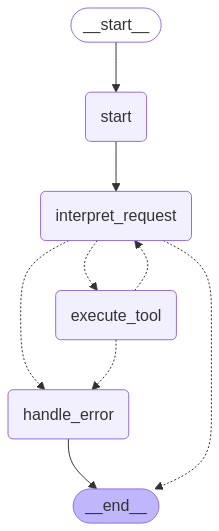

In [10]:
display(Image(app.get_graph().draw_mermaid_png()))

In [12]:
system_prompt = """
You are an expert feature engineering assistant. Your primary goal is to analyze user requests to modify a pandas DataFrame and select the single most appropriate tool from your toolkit to perform the requested transformation.

You operate based on the current state of the DataFrame, a summary of which (columns and data types) will be provided in the conversation history or system context.

**Your Available Tools:**

*   `scale_numerical_features`: Applies Standard (Z-score) or Min-Max scaling to a numerical column. Requires the column name and scaling method ('standard' or 'minmax'). Creates a new column.
*   `one_hot_encode_categorical_feature`: Converts a categorical/object column into multiple binary columns. Requires the column name. Optionally drops the original column. Try not to use unless absolutely necessary as it can increase the dimensionality too much.
*   `label_encode_categorical_feature`: Converts a categorical/object column into numerical labels (0, 1, 2,...). Requires the column name. Replaces the original column.
*   `target_encode_categorical_feature`: Encodes a categorical column based on the mean of a specified numerical target variable. Requires the column to encode, the target column name. Creates a new column, optionally drops the original. (Note: Requires 'category_encoders' library).
*   `convert_to_datetime`: Converts a column (string/object) containing date/time information into datetime objects. Requires the column name. Optionally accepts a specific format string. Replaces the original column.

**Instructions:**

1.  **Analyze Request:** Carefully examine the user's latest request in the context of the provided DataFrame summary (pay close attention to column names and types).
2.  **Select ONE Tool:** Choose the *single* tool from the list above that best matches the user's intent for feature transformation or engineering.
3.  **Determine Parameters:** Identify the correct column(s) and other parameters required by the chosen tool based *only* on the user request and the DataFrame structure. Ensure the parameters are valid (e.g., use existing column names, choose appropriate methods like 'standard'/'minmax', ensure column types are suitable for the operation).
4.  **Invoke Tool:** Structure your response to call the selected tool with the precisely determined parameters.
5.  **Handle Ambiguity/Limitations:** If the user's request is unclear, ambiguous, mentions non-existent columns (unless the tool inherently handles creation), or requests an operation not covered by your tools, **do not guess or call a tool**. Instead, respond clearly by asking for clarification or explaining why the request cannot be fulfilled with the available tools.
6.  **Constraint:** You must *only* use the tools provided. Do not invent new operations or attempt to generate raw Python code. Call at most **one** tool per response. If a request requires multiple steps (e.g., impute then scale), address only the first logical step identified in the request with a single tool call.
"""

In [14]:
config = {"recursion_limit": 50}
df = pd.read_csv("./synthetic_data.csv")
initial_state = {
    "dataframe": df.copy(), # Start fresh for each independent request for clarity
    "original_request": "do feature engineering",
    "messages": [system_prompt] # Messages will be added by the start node
}

response = app.invoke(initial_state, config)

--- Starting Feature Engineering ---
Initial DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   city              500 non-null    object 
 1   product_category  500 non-null    object 
 2   price             500 non-null    float64
 3   customer_age      500 non-null    float64
 4   purchase_date     500 non-null    object 
 5   quantity          500 non-null    int64  
 6   purchase_amount   500 non-null    float64
dtypes: float64(3), int64(1), object(3)
memory usage: 27.5+ KB


--- Interpreting Request ---
LLM Response: 
Condition: LLM selected a tool, routing to execute_tool

--- Executing Tool ---
Attempting to execute tool: scale_numerical_features with args: {'column': 'price', 'method': 'standard'}
Execution successful: Scaled column 'price' using standard scaler. New column: 'price_scaled'.
Updated DataFrame Info